In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'
from tqdm import tqdm

from joblib import Parallel, delayed

import pickle

import schwingerModel as sim

import scipy.sparse as sparse

In [2]:
def coshCorrel(nt, Energy, pivot,dimt):
    num = np.exp(-nt*Energy)+np.exp((nt-dimt)*Energy)
    denom = np.exp(-pivot*Energy)+np.exp((pivot-dimt)*Energy)
    return num/denom

In [3]:
# with open('configs/50kSteps.pkl', 'rb') as f:
#     a1 = pickle.load(f)

In [4]:
# sim.distillation.generateDistillFile(modelObj=a1,filePath="./configs/50kSteps.hdf5",numVecs=7,autocorrSkip=50,DNums=(0,2))

In [14]:
path = "./configs/50kSteps.hdf5"
meta = sim.distillation.readDistillMeta(path)
basis = [sim.distillation.MesonOp("g5"),sim.distillation.MesonOp("g5",DNum=2),sim.distillation.MesonOp("gx"),sim.distillation.MesonOp("gx",DNum=2)]
corrs = sim.GEVP.measureEnsemble2pt(path,np.arange(0,50000,50),basis=basis)

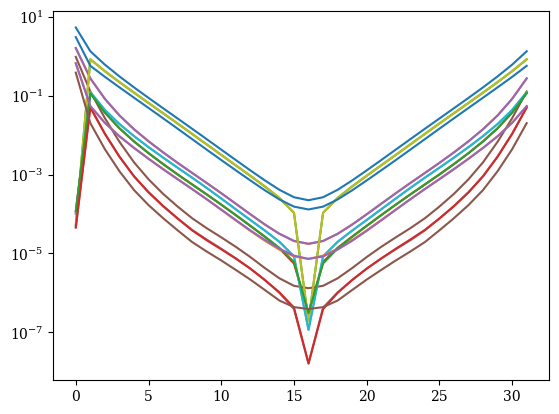

In [16]:
plt.semilogy(np.abs(np.reshape(corrs[0],(16,-1)).T))

In [17]:
gevpTi = 2   # reference time used inside gevpReduce: lambda(gevpTi) = 1, curves start there

gevpOut = sim.GEVP.bootstrapEnsemble2pt(corrs, reduce=lambda C: sim.GEVP.gevpReduce(C, ti=gevpTi))

In [18]:
# fitT is in curve-index units m = t - gevpTi; window [3,6] = actual times 4..6

m0 = sim.correlation.gevpMassExtract(gevpOut, fitT=[6,12], ti=gevpTi, eigenIdx=0,coshExpr=False)
m1 = sim.correlation.gevpMassExtract(gevpOut, fitT=[6,12], ti=gevpTi, eigenIdx=1,coshExpr=False)

In [21]:
print(m0)
print(m1)

[0.55892677 0.00099089]
[0.90182559 0.0082096 ]


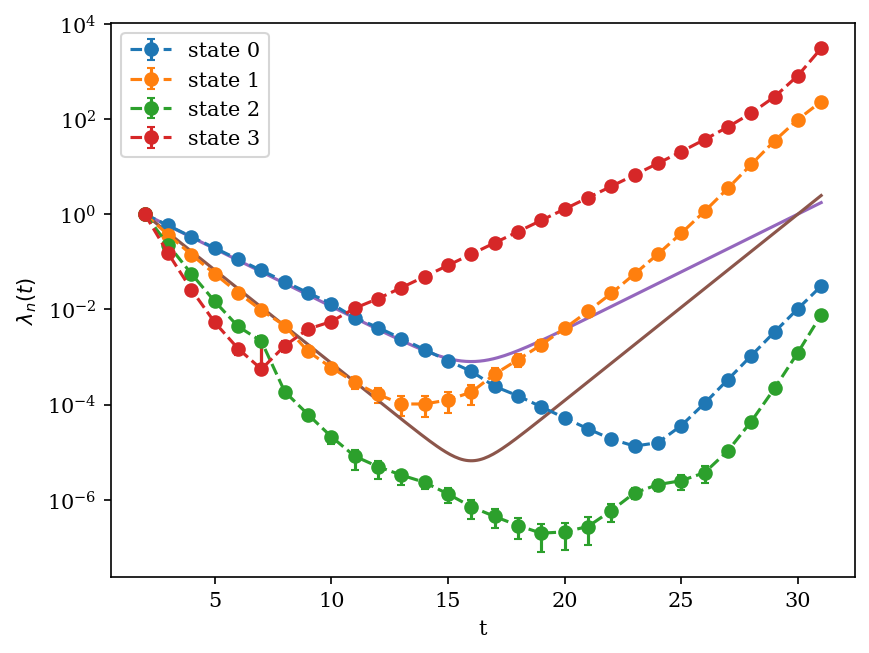

In [19]:
central, err, cov = gevpOut

ts = np.arange(gevpTi, gevpTi + central.shape[0])   # actual times: gevpTi .. dimt-1

plt.figure(dpi=150)
for e in range(central.shape[1]):
    plt.errorbar(ts, central[:, e], yerr=err[::-1, :, e],
                 fmt='o--', capsize=2, label=f"state {e}")

# cosh references: same pivot as the gevp normalization, explicit x-axis
tf = np.linspace(gevpTi, meta.dimt - 1, 300)
plt.plot(tf, coshCorrel(tf, m0[0], gevpTi, meta.dimt))
plt.plot(tf, coshCorrel(tf, m1[0], gevpTi, meta.dimt))

plt.semilogy()
plt.xlabel("t"); plt.ylabel(r"$\lambda_n(t)$")
plt.legend()

IndexError: list index out of range

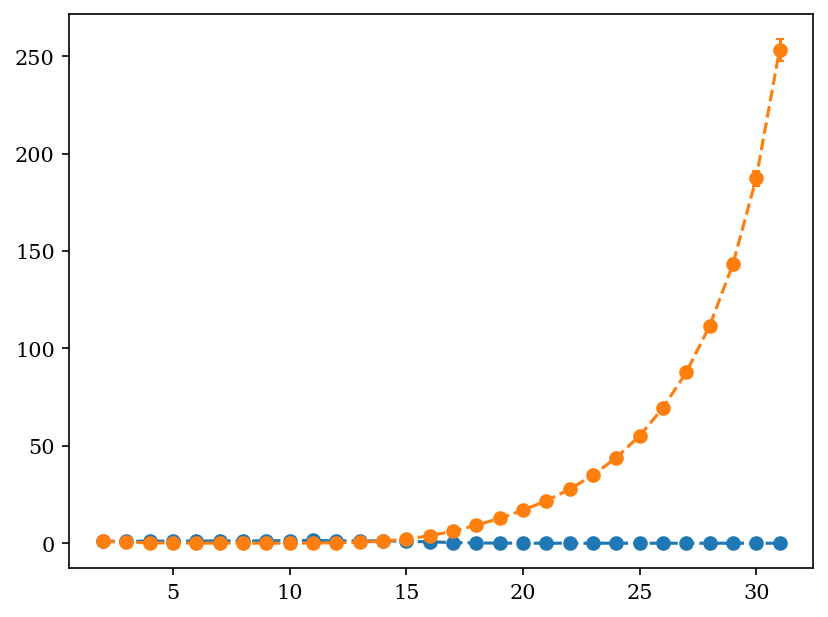

In [13]:
fits = [coshCorrel(ts, m0[0], gevpTi, meta.dimt), coshCorrel(ts, m1[0], gevpTi, meta.dimt)]

plt.figure(dpi=150)
for e in range(central.shape[1]):
    plt.errorbar(ts, central[:, e]/fits[e], yerr=err[::-1, :, e]/fits[e],
                 fmt='o--', capsize=2, label=f"state {e}")
plt.xlabel("t"); plt.ylabel(r"$\lambda_n(t)/C(E=m)$")
plt.legend()
plt.semilogy()